In [ ]:
# Run once, then restart the kernel.
!pip install -q -U "langchain>=1.3" "langgraph>=1.2" "langchain-openai>=1.1" "tavily-python>=0.7" requests python-dotenv

In [2]:
import os
import json

from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain.messages import HumanMessage, SystemMessage

load_dotenv()

API_KEY = os.getenv("NVIDIA_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "NVIDIA_API_KEY not found. "
        "Copy .env.example to .env, paste your key into it, then restart the kernel."
    )

MODEL = "nvidia/nemotron-3.5-lightning-30b-a3b"

# Thinking is ON deliberately: Nemotron only emits tool calls in reasoning mode.
# With enable_thinking=False it answers from memory and never touches your tools.
llm = ChatOpenAI(
    model=MODEL,
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=API_KEY,
    temperature=1,
    top_p=0.95,
    max_tokens=16384,
    extra_body={
        "chat_template_kwargs": {"enable_thinking": True},
        "reasoning_budget": 16384,
    },
)

print("Setup complete. Model:", MODEL)

C:\Users\shiva\.pyenv\pyenv-win\versions\3.12.10\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Model: nvidia/nemotron-3.5-lightning-30b-a3b


## 2. The tools - unchanged from Notebook 3

Plain Python functions. No LangChain in sight yet. `get_weather` hits Open-Meteo (no key needed);
`web_search` uses Tavily and degrades to a clear error message if `TAVILY_API_KEY` is missing.

In [3]:
import requests
from tavily import TavilyClient

WEATHER_CODES = {
    0: "clear sky", 1: "mainly clear", 2: "partly cloudy", 3: "overcast",
    45: "foggy", 48: "depositing rime fog",
    51: "light drizzle", 53: "moderate drizzle", 55: "dense drizzle",
    61: "slight rain", 63: "moderate rain", 65: "heavy rain",
    71: "slight snow", 73: "moderate snow", 75: "heavy snow",
    80: "slight rain showers", 81: "moderate rain showers", 82: "violent rain showers",
    95: "thunderstorm", 96: "thunderstorm with hail", 99: "thunderstorm with heavy hail",
}


def get_weather(city: str) -> dict:
    """Current weather for a city, via Open-Meteo (no API key needed)."""
    geo = requests.get("https://geocoding-api.open-meteo.com/v1/search",
                       params={"name": city, "count": 1}, timeout=15).json()
    if not geo.get("results"):
        return {"error": f"Could not find a place called '{city}'."}
    place = geo["results"][0]

    w = requests.get("https://api.open-meteo.com/v1/forecast", params={
        "latitude": place["latitude"], "longitude": place["longitude"],
        "current": "temperature_2m,relative_humidity_2m,precipitation,weather_code,wind_speed_10m",
        "timezone": "auto"}, timeout=15).json()["current"]

    return {
        "city": place["name"], "country": place.get("country", ""),
        "temperature_c": w["temperature_2m"], "humidity_percent": w["relative_humidity_2m"],
        "precipitation_mm": w["precipitation"], "wind_kmh": w["wind_speed_10m"],
        "conditions": WEATHER_CODES.get(w["weather_code"], "unknown"),
        "observed_at": w["time"],
    }


TAVILY_KEY = os.getenv("TAVILY_API_KEY")
tavily = TavilyClient(api_key=TAVILY_KEY) if TAVILY_KEY else None


def web_search(query: str, max_results: int = 3) -> dict:
    """Search the web via Tavily."""
    if tavily is None:
        return {"error": "TAVILY_API_KEY is not set. Get a free key at tavily.com and add it to .env."}
    response = tavily.search(query=query, max_results=max_results)
    return {"query": query, "results": [
        {"title": r["title"], "url": r["url"], "snippet": r["content"][:300]}
        for r in response["results"]]}


print("get_weather :", get_weather("Coimbatore")["temperature_c"], "degC")
print("web_search  :", "ready" if tavily else "no TAVILY_API_KEY (search cells will be skipped)")

get_weather : 29.9 degC
web_search  : ready


## 3. The schemas you wrote by hand

This is the part of Notebook 3 that LangChain deletes. Keep it on screen for one more minute -
we are about to generate it.

In [4]:
weather_tool = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get the current weather for a city. Use this whenever the user asks "
                       "about current temperature, rain, or conditions.",
        "parameters": {
            "type": "object",
            "properties": {"city": {"type": "string", "description": "The city name, e.g. 'Coimbatore'."}},
            "required": ["city"],
        },
    },
}

search_tool = {
    "type": "function",
    "function": {
        "name": "web_search",
        "description": "Search the web for current information, news, facts, or anything that "
                       "happened recently. Use when you do not know the answer.",
        "parameters": {
            "type": "object",
            "properties": {"query": {"type": "string", "description": "The search query."}},
            "required": ["query"],
        },
    },
}

TOOL_SCHEMAS = [weather_tool, search_tool]
print("2 tool schemas ready.")

2 tool schemas ready.


## 4. The LangChain way - `@tool`

`@tool` turns a Python function into a `BaseTool`: it reads the **name** from the function, the
**description** from the docstring, and the **parameter schema** from the type hints. The dict in
section 3 stops being something you maintain.

Our two functions already exist, so instead of re-typing them under a decorator we apply `tool()`
in its function form. We reuse the hand-written descriptions from section 3 - those sentences were
good prompt engineering ("use this whenever...") and better than the one-line docstrings.

> **The description is prompt engineering.** It is the only thing the model reads when deciding
> whether to call your tool. A vague description is a tool the model ignores.

In [5]:
get_weather_tool = tool(
    "get_weather",
    description=weather_tool["function"]["description"],
)(get_weather)

web_search_tool = tool(
    "web_search",
    description=search_tool["function"]["description"],
)(web_search)

tools = [get_weather_tool, web_search_tool]

for t in tools:
    print(f"{t.name:12s} args={list(t.args.keys())}")

get_weather  args=['city']
web_search   args=['query', 'max_results']


### 4.1 Proof: the generated schema is the schema you wrote

`convert_to_openai_tool` shows exactly what LangChain will send over the wire. Compare it against
`weather_tool` in section 3 - same shape, same `required` list, and it came from
`def get_weather(city: str)`.

In [6]:
from langchain_core.utils.function_calling import convert_to_openai_tool

generated = convert_to_openai_tool(get_weather_tool)
print(json.dumps(generated, indent=2))

print("\nhand-written name :", weather_tool["function"]["name"])
print("generated name    :", generated["function"]["name"])
print("same required[]   :",
      weather_tool["function"]["parameters"]["required"]
      == generated["function"]["parameters"]["required"])

{
  "type": "function",
  "function": {
    "name": "get_weather",
    "description": "Get the current weather for a city. Use this whenever the user asks about current temperature, rain, or conditions.",
    "parameters": {
      "properties": {
        "city": {
          "type": "string"
        }
      },
      "required": [
        "city"
      ],
      "type": "object"
    }
  }
}

hand-written name : get_weather
generated name    : get_weather
same required[]   : True


One thing is missing, and it matters: the **per-argument** descriptions. Your hand-written dict said
`"The city name, e.g. 'Coimbatore'."`; a type hint cannot say that. Put it back with `Annotated`
(or a Pydantic `args_schema`) - the model reads these too.

In [7]:
from typing import Annotated


def get_weather_documented(
    city: Annotated[str, "The city name, e.g. 'Coimbatore'."],
) -> dict:
    """Current weather for a city."""
    return get_weather(city)


documented_tool = tool(
    "get_weather",
    description=weather_tool["function"]["description"],
)(get_weather_documented)

print(json.dumps(convert_to_openai_tool(documented_tool)["function"]["parameters"], indent=2))

{
  "properties": {
    "city": {
      "description": "The city name, e.g. 'Coimbatore'.",
      "type": "string"
    }
  },
  "required": [
    "city"
  ],
  "type": "object"
}


Note `web_search` too: its `max_results: int = 3` default shows up as an *optional* parameter, so
the model may set it. That is the trade-off of generated schemas - the signature **is** the
contract. Hide a parameter from the model by giving the tool a narrower wrapper function.

In [8]:
print(json.dumps(convert_to_openai_tool(web_search_tool)["function"]["parameters"], indent=2))

{
  "properties": {
    "query": {
      "type": "string"
    },
    "max_results": {
      "default": 3,
      "type": "integer"
    }
  },
  "required": [
    "query"
  ],
  "type": "object"
}


## 5 

By default the model *decides* whether to call a tool (`tool_choice="auto"`). Pass
`tool_choice="required"` to `bind_tools` and it **must** emit at least one tool call - even for
"hello". Same knob you used in the raw OpenAI call in Notebook 2, one level up.

Values LangChain accepts:

| value | meaning |
|---|---|
| `"auto"` | model decides (default) |
| `"required"` (or `"any"`, or `True`) | must call some tool |
| `"get_weather"` | must call *that* tool |
| `"none"` | may not call any tool |

In [ ]:
auto_llm     = llm.bind_tools(tools)                          # tool_choice="auto" by default 

GREETING = "Hi there! Just saying hello, nothing to look up."

print("tool_calls:", auto_llm.invoke([HumanMessage(GREETING)]).tool_calls)

## 6. The agent - `create_agent`

Now the loop. `create_agent(model, tools, system_prompt=...)` returns a compiled LangGraph graph
that does exactly what your hand-written `while` loop did: model -> tools -> model -> ... until the
model stops asking for tools.

In [12]:
from langchain.agents import create_agent

SYSTEM = (
    "You are a concise assistant with two tools: live weather and web search. "
    "Always use a tool to get facts rather than answering from memory. "
    "Answer in at most three sentences, and name the source of your numbers."
)

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM,
)

result = agent.invoke({"messages": [HumanMessage("What is the weather in Coimbatore right now?")]})
print(result["messages"][-1].content)

The current temperature in Coimbatore is about 30 °C with a humidity of 62 % and light drizzle (0.3 mm precipitation). Source: live weather data from the get_weather tool.


Every message of the run is in `result["messages"]` - the same transcript you were building by hand.

In [13]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the weather in Coimbatore right now?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call-8b742d97-a2d3-4b7b-b37a-142e291607c4)
 Call ID: call-8b742d97-a2d3-4b7b-b37a-142e291607c4
  Args:
    city: Coimbatore
================================= Tool Message =================================
Name: get_weather

{"city": "Coimbatore", "country": "India", "temperature_c": 29.9, "humidity_percent": 62, "precipitation_mm": 0.3, "wind_kmh": 15.9, "conditions": "dense drizzle", "observed_at": "2026-09-01T14:00"}
================================== Ai Message ==================================

The current temperature in Coimbatore is about 30 °C with a humidity of 62 % and light drizzle (0.3 mm precipitation). Source: live weather data from the get_weather tool.


## 8. What you get for free once the loop is a graph

The rest of this notebook is the payoff for giving up your `while` loop.

### 8.1 See the loop

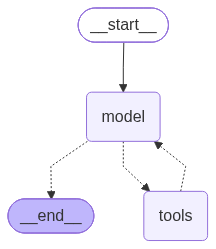

In [17]:
from IPython.display import Image, display


def show_graph(graph):
    """Render a compiled graph. Falls back to Mermaid source if there is no network."""
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        print(graph.get_graph().draw_mermaid())


show_graph(agent)

### 8.2 Stream every step

You were printing debug lines inside your own loop. Here the loop reports itself.

In [18]:
QUESTION = "Compare the current temperature in Coimbatore and Bengaluru. Which is warmer?"

for step, payload in enumerate(agent.stream({"messages": [HumanMessage(QUESTION)]},
                                            stream_mode="updates"), start=1):
    for node_name, node_state in payload.items():
        msg = node_state["messages"][-1]
        preview = (msg.content or "").strip().replace("\n", " ")[:110]
        calls = getattr(msg, "tool_calls", None)
        extra = f" -> calls {[c['name'] for c in calls]}" if calls else ""
        print(f"step {step}  [{node_name}] {type(msg).__name__}: {preview}{extra}")

step 1  [model] AIMessage:  -> calls ['get_weather']


step 2  [tools] ToolMessage: {"city": "Coimbatore", "country": "India", "temperature_c": 29.9, "humidity_percent": 62, "precipitation_mm": 


step 3  [model] AIMessage:  -> calls ['get_weather']


step 4  [tools] ToolMessage: {"city": "Bengaluru", "country": "India", "temperature_c": 28.6, "humidity_percent": 55, "precipitation_mm": 0


step 5  [model] AIMessage: Coimbatore is warmer at 29.9 °C, while Bengaluru is 28.6 °C, according to live weather data observed at 14:00 


### 8.2 A structured answer instead of prose

Agents end in prose by default. `response_format` adds one validated object in
`result["structured_response"]` - useful when the agent feeds code rather than a human.

In [ ]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import ToolStrategy


class WeatherReport(BaseModel):
    """A weather answer your code can use directly."""
    city: str = Field(description="City the report is about.")
    temperature_c: float = Field(description="Current temperature in Celsius.")
    conditions: str = Field(description="Short description of the conditions.")
    umbrella_needed: bool = Field(description="True if rain or showers are reported.")


report_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM + " Finish every weather question by filling in the WeatherReport schema.",
    response_format=ToolStrategy(WeatherReport),
)

out = report_agent.invoke({"messages": [HumanMessage("Weather in Coimbatore?")]})
report = out.get("structured_response")

if report is None:
    # ToolStrategy asks for one *extra* tool call; a small model sometimes answers in prose
    # instead. Always check before you index - and say so in your own code, do not assume.
    print("No structured_response - the model answered in prose:")
    print(out["messages"][-1].content)
else:
    print(report)
    print("\numbrella_needed is a real bool:", isinstance(report.umbrella_needed, bool))

  [middleware] model call -> tool_choice='required'


  [middleware] model call -> tool_choice='auto'


city='Coimbatore' temperature_c=29.9 conditions='dense drizzle' umbrella_needed=True

umbrella_needed is a real bool: True


## 9. Notebook 3 vs Notebook 6

| What you wrote by hand | What replaced it |
|---|---|
| ~35 lines of JSON tool schemas | `@tool` / `tool(...)` reading your type hints |
| `while` loop with a step cap | The compiled graph, `model <-> tools` |
| `if name == ...: fn(**args)` dispatch | `ToolNode`, by tool name |
| `messages.append(...)` bookkeeping | Graph state |

**The one thing that did not change: your tool functions.** Tools are portable; only the
orchestration is framework-shaped. That is why we wrote the loop by hand first.

### Exercises

1. Add a third tool - `get_forecast(city, days)` off the same Open-Meteo `daily` endpoint - and ask
   the agent a question that needs both it and `get_weather`.
2. Change `require_tool_on_first_call` so it forces `tool_choice="get_weather"` (one specific tool)
   whenever the user's message mentions weather, and `"auto"` otherwise.